URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 5.2. Time/frequency statistics

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p5/tf](https://zzz.bwh.harvard.edu/luna-walkthrough/p5/tf)

---


In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../c.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x12098b5b0> 

read 20 individuals from ../c.lst


In [2]:
import sys
sys.path.append('../')
from helperfuncs import fit_lm, fit_lms, safe_to_numeric, ttests_by_F

## Spectral analysis

Here we'll run three flavors of spectral analysis implemented in Luna:

 - power from the Welch method as implemented by the `PSD` command

 - power from the multitaper method as implemented by the `MTM` command

 - estimates of periodic and aperiodic components of the power spectra, from the irregular-resampling auto-spectral analysis method as implemented by the `IRASA` command

We'll run these separately for N2 and REM sleep, illustrating Luna's `FREEZE`/`THAW` mechanism to snapshot the data (rather than as separate jobs). As `IRASA` is relatively slow to run, we'll restrict these analyses to four midline channels (FZ, CZ, PZ and OZ, defined as the Luna variable `${z}`):  

(__Note: This will take several minutes to complete for all channels/individuals.__)

In [3]:
#luna c.lst  -o out/spectral.db \
#  -s ' ${z=FZ,CZ,PZ,OZ}
#      FILTER sig=${z} bandpass=0.3,60 tw=0.3,5 ripple=0.01,0.01
#      FREEZE F1
#      TAG stg/N2
#      MASK ifnot=N2 & RE
#      CHEP-MASK sig=${z} ep-th=3,3
#      CHEP sig=${z} epochs & RE
#      PSD sig=${z} dB spectrum max=30
#      MTM sig=${z} epoch max=30 dB tw=15 mean-center
#      IRASA sig=${z} dB
#      THAW F1
#      TAG stg/R
#      MASK ifnot=R & RE
#      CHEP-MASK sig=${z} ep-th=3,3
#      CHEP sig=${z} epochs & RE
#      PSD sig=${z} dB spectrum max=30 
#      MTM sig=${z} epoch max=30 dB tw=15 mean-center
#      IRASA sig=${z} dB '

res = proj.silent_proc( '''
      ${z=FZ,CZ,PZ,OZ} 
      FILTER sig=${z} bandpass=0.3,60 tw=0.3,5 ripple=0.01,0.01
      FREEZE F1
      TAG stg/N2
      MASK ifnot=N2 & RE
      CHEP-MASK sig=${z} ep-th=3,3
      CHEP sig=${z} epochs & RE
      PSD sig=${z} dB spectrum max=30
      MTM sig=${z} epoch max=30 dB tw=15 mean-center
      IRASA sig=${z} dB
      THAW F1
      TAG stg/R
      MASK ifnot=R & RE
      CHEP-MASK sig=${z} ep-th=3,3
      CHEP sig=${z} epochs & RE
      PSD sig=${z} dB spectrum max=30 
      MTM sig=${z} epoch max=30 dB tw=15 mean-center
      IRASA sig=${z} dB 
      ''' )


Extracting three output tables/dataframes:

In [4]:
# destrat out/spectral.db +MTM -r F CH stg > res/spectral.mtm
# destrat out/spectral.db +PSD -r F CH stg > res/spectral.welch
# destrat out/spectral.db +IRASA -r F CH stg > res/spectral.irasa

df_mtm   = safe_to_numeric( proj.table( 'MTM' , 'CH_F_stg' ) ) 
df_welch = safe_to_numeric( proj.table( 'PSD' , 'CH_F_stg' ) )
df_irasa = safe_to_numeric( proj.table( 'IRASA' , 'CH_F_stg' ) )

Finally, we'll merge in the demographic data:

In [5]:
#p <- read.table("work/data/auxiliary/master.txt",header=T, stringsAsFactors=F)
#welch <- merge( welch , p , by="ID" )
#mtm   <- merge( mtm , p , by="ID" )
#irasa <- merge( irasa , p , by="ID" )

import pandas as pd
p = pd.read_csv( '../work/data/auxiliary/master.txt' , sep="\t" ) 

df_mtm   = pd.merge( p , df_mtm , on = 'ID' ) 
df_welch = pd.merge( p , df_welch , on = 'ID' ) 
df_irasa = pd.merge( p , df_irasa , on = 'ID' ) 


## Group averages

A good starting point is to plot whole-sample and group-specific (male/female) means. First for Welch/PSD, we get means stratified by a) frequency bin, b) channel, c) sleep stage and d) sex:

In [6]:
# m.welch <- tapply(welch$PSD, list(welch$F, welch$CH, welch$stg, welch$male), mean )
#df_welch
mns = df_welch.groupby( [ 'stg' , 'CH', 'F', 'male' ] )['PSD'].mean()
mns.unstack()

male                  0          1
stg CH F                          
N2  CZ 0.50   21.422520  20.328803
       0.75   21.446529  19.530497
       1.00   20.725130  18.600372
       1.25   19.534794  17.289934
       1.50   18.210924  16.233922
...                 ...        ...
R   PZ 29.00 -10.120187 -10.986113
       29.25 -10.246535 -11.149291
       29.50 -10.371683 -11.208265
       29.75 -10.482306 -11.372075
       30.00 -10.547825 -11.481366

[952 rows x 2 columns]

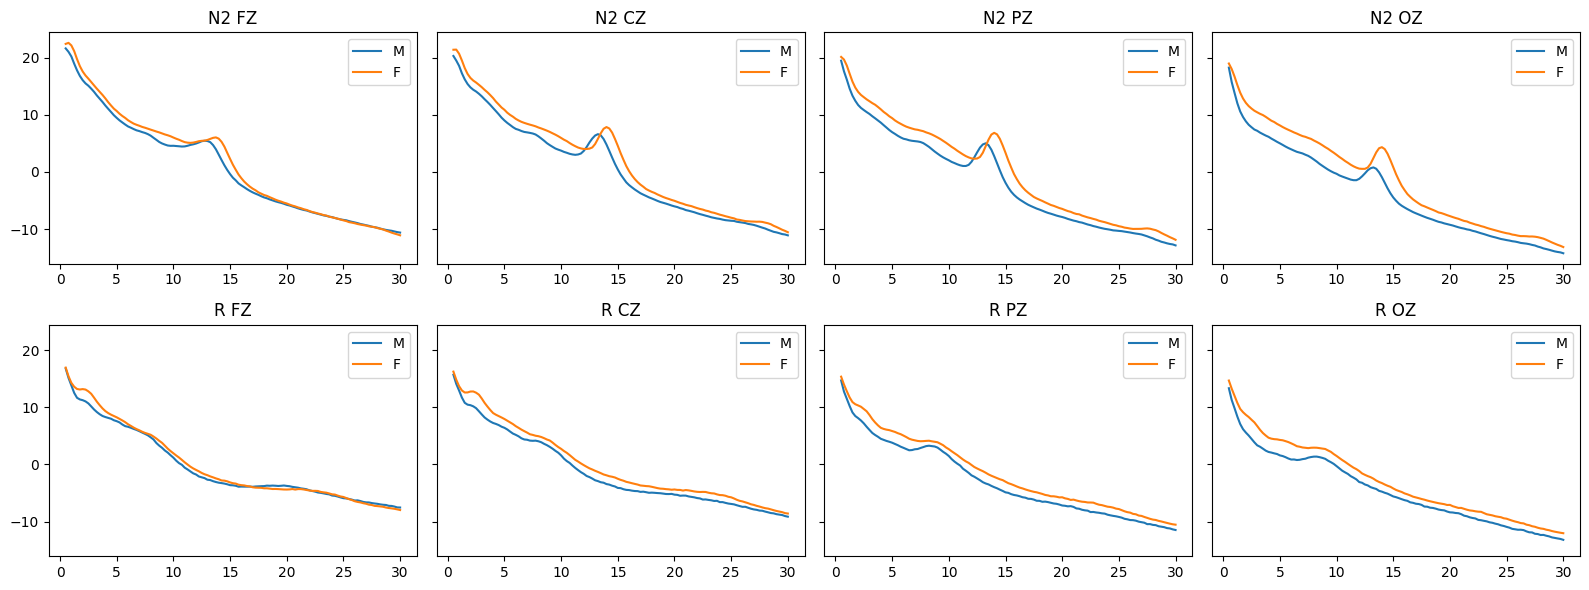

In [7]:
# plot M/F PSD for N2 & REM for four channels:

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey = True )  # 2 rows, 4 columns

idx = 0
for stg in [ 'N2', 'R' ]:
    for ch in [ 'FZ', 'CZ', 'PZ', 'OZ' ]:
        ax = axes.flat[idx]
        xs_males = mns.xs(( stg, ch, 1), level=('stg', 'CH', 'male'))
        xs_females = mns.xs(( stg, ch, 0), level=('stg', 'CH', 'male'))
        ax.plot( xs_males.index , xs_males.values , label = 'M' )
        ax.plot( xs_females.index , xs_females.values , label = 'F' )
        ax.legend()
        ax.set_title( stg + " " + ch )
        idx = idx + 1
plt.tight_layout()
plt.show()

Comparing the Welch and MTM spectra:

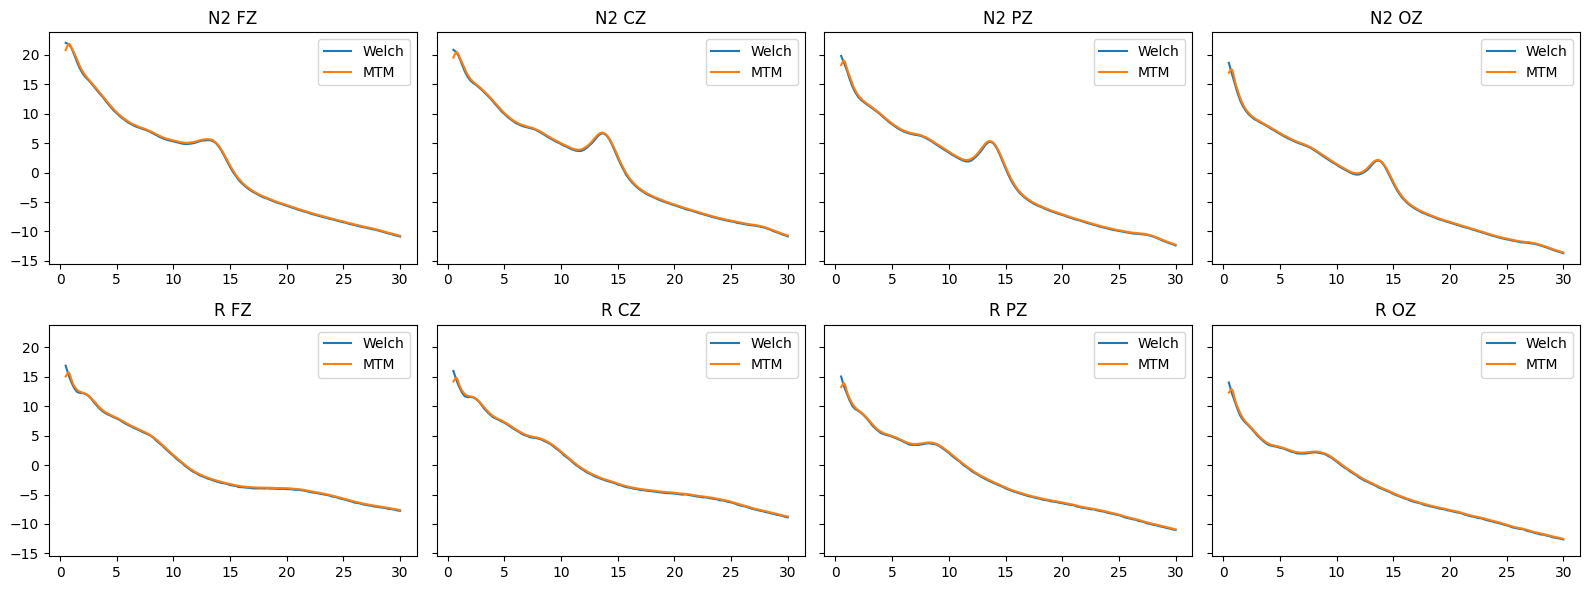

In [8]:
#m.welch <- tapply( welch$PSD , list( welch$F , welch$CH , welch$stg ) , mean )
#m.mtm   <- tapply( mtm$MTM , list( mtm$F , mtm$CH , mtm$stg ) , mean )

mns_welch = df_welch.groupby( [ 'stg' , 'CH', 'F' ] )['PSD'].mean()
mns_mtm = df_mtm.groupby( [ 'stg' , 'CH', 'F' ] )['MTM'].mean()

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey = True )  # 2 rows, 4 columns
idx = 0
for stg in [ 'N2', 'R' ]:
    for ch in [ 'FZ', 'CZ', 'PZ', 'OZ' ]:
        ax = axes.flat[idx]
        xs_welch = mns_welch.xs(( stg, ch ), level=('stg', 'CH' ))
        xs_mtm = mns_mtm.xs(( stg, ch ), level=('stg', 'CH' ))
        ax.plot( xs_welch.index , xs_welch.values , label = 'Welch' )
        ax.plot( xs_mtm.index , xs_mtm.values , label = 'MTM' )
        ax.legend()
        ax.set_title( stg + " " + ch )
        idx = idx + 1
plt.tight_layout()
plt.show()

Next turning to `IRASA`:

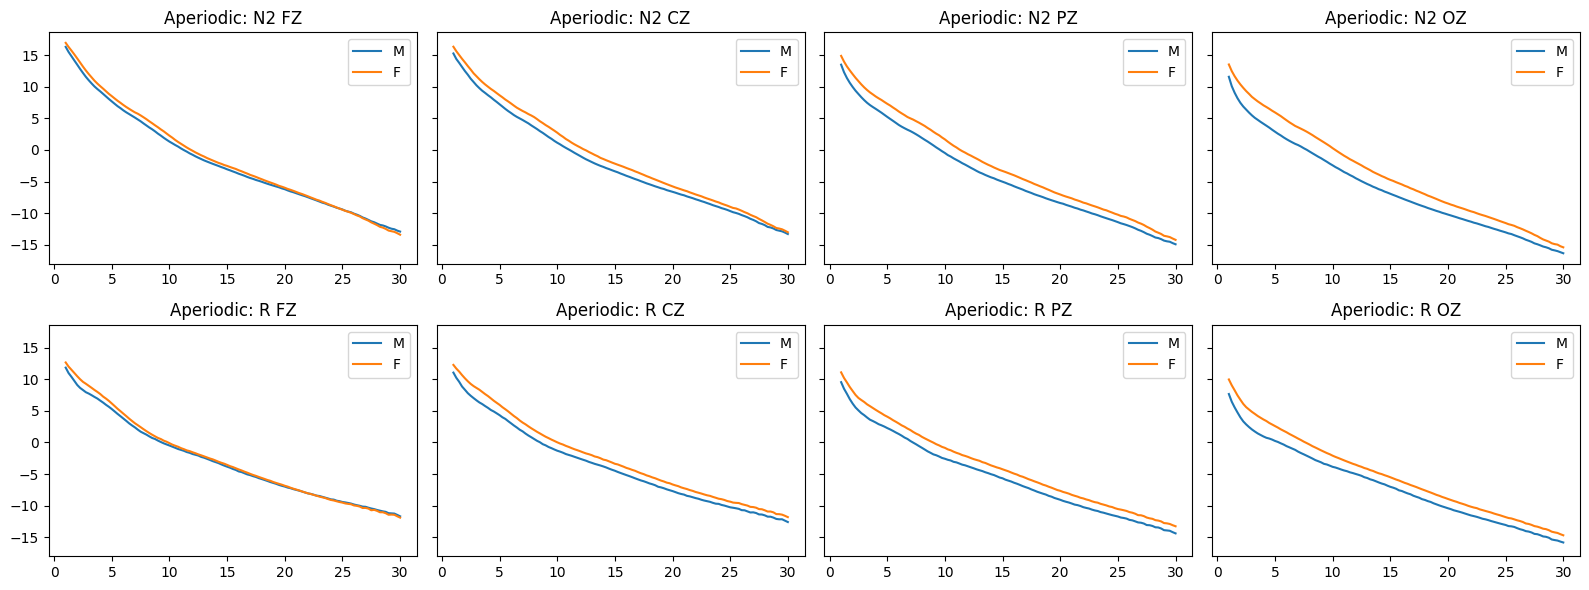

In [9]:
#m.aper <- tapply( irasa$APER , list( irasa$F , irasa$CH , irasa$stg , irasa$male ) , mean )
#m.per  <- tapply( irasa$PER  , list( irasa$F , irasa$CH , irasa$stg , irasa$male ) , mean )

mns_aper = df_irasa.groupby( [ 'stg' , 'CH', 'F', 'male' ] )['APER'].mean()
mns_per = df_irasa.groupby( [ 'stg' , 'CH', 'F', 'male' ] )['PER'].mean()

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey = True )  # 2 rows, 4 columns
idx = 0
for stg in [ 'N2', 'R' ]:
    for ch in [ 'FZ', 'CZ', 'PZ', 'OZ' ]:
        ax = axes.flat[idx]
        xs_males = mns_aper.xs(( stg, ch , 1), level=('stg', 'CH', 'male' ))
        xs_females = mns_aper.xs(( stg, ch, 0 ), level=('stg', 'CH', 'male' ))
        ax.plot( xs_males.index , xs_males.values , label = 'M' )
        ax.plot( xs_females.index , xs_females.values , label = 'F' )
        ax.legend()
        ax.set_title( "Aperiodic: " + stg + " " + ch )
        idx = idx + 1
plt.tight_layout()
plt.show()

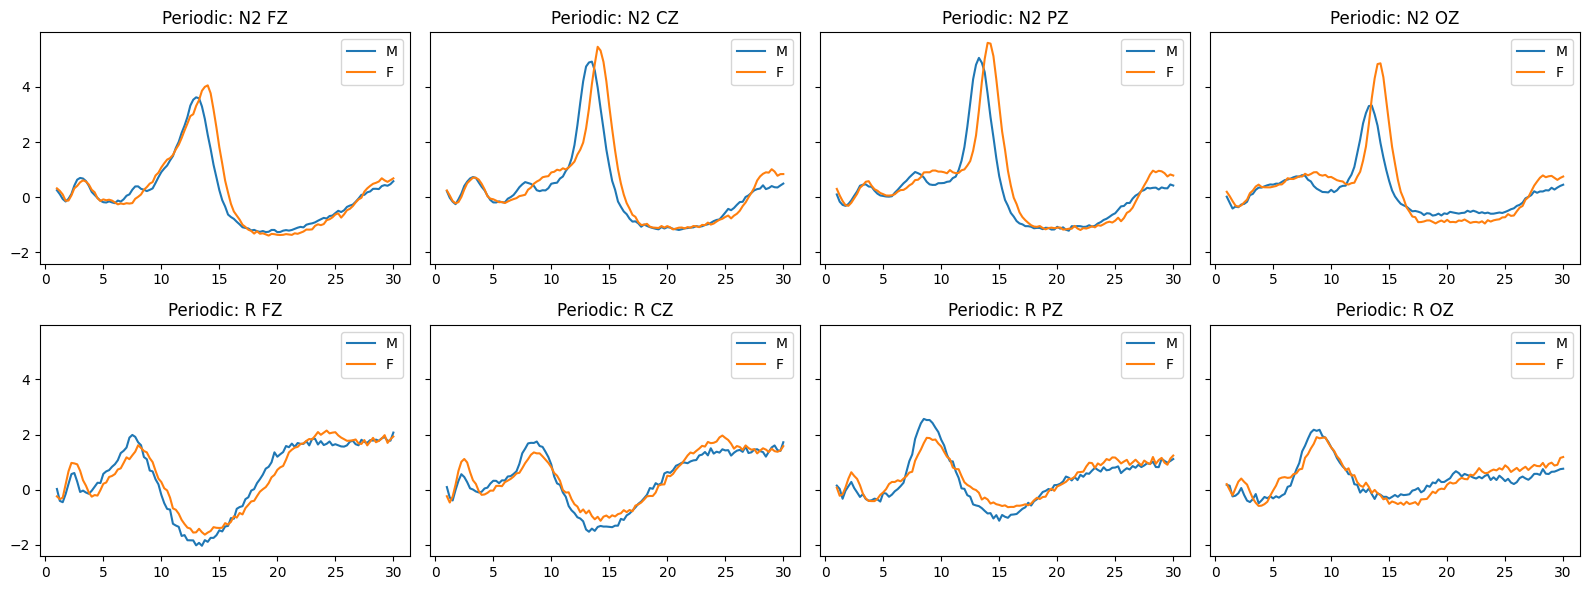

In [10]:
# repeating for the periodic IRASA components

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey = True )  # 2 rows, 4 columns
idx = 0
for stg in [ 'N2', 'R' ]:
    for ch in [ 'FZ', 'CZ', 'PZ', 'OZ' ]:
        ax = axes.flat[idx]
        df_males = mns_per.xs(( stg, ch , 1), level=('stg', 'CH', 'male' ))
        df_females = mns_per.xs(( stg, ch, 0 ), level=('stg', 'CH', 'male' ))
        ax.plot( df_males.index , df_males.values , label = 'M' )
        ax.plot( df_females.index , df_females.values , label = 'F' )
        ax.legend()
        ax.set_title( "Periodic: " + stg + " " + ch )
        idx = idx + 1
plt.tight_layout()
plt.show()

## Individual spectra

Displaying Welch power spectra for all individuals (with lines colored by sex):

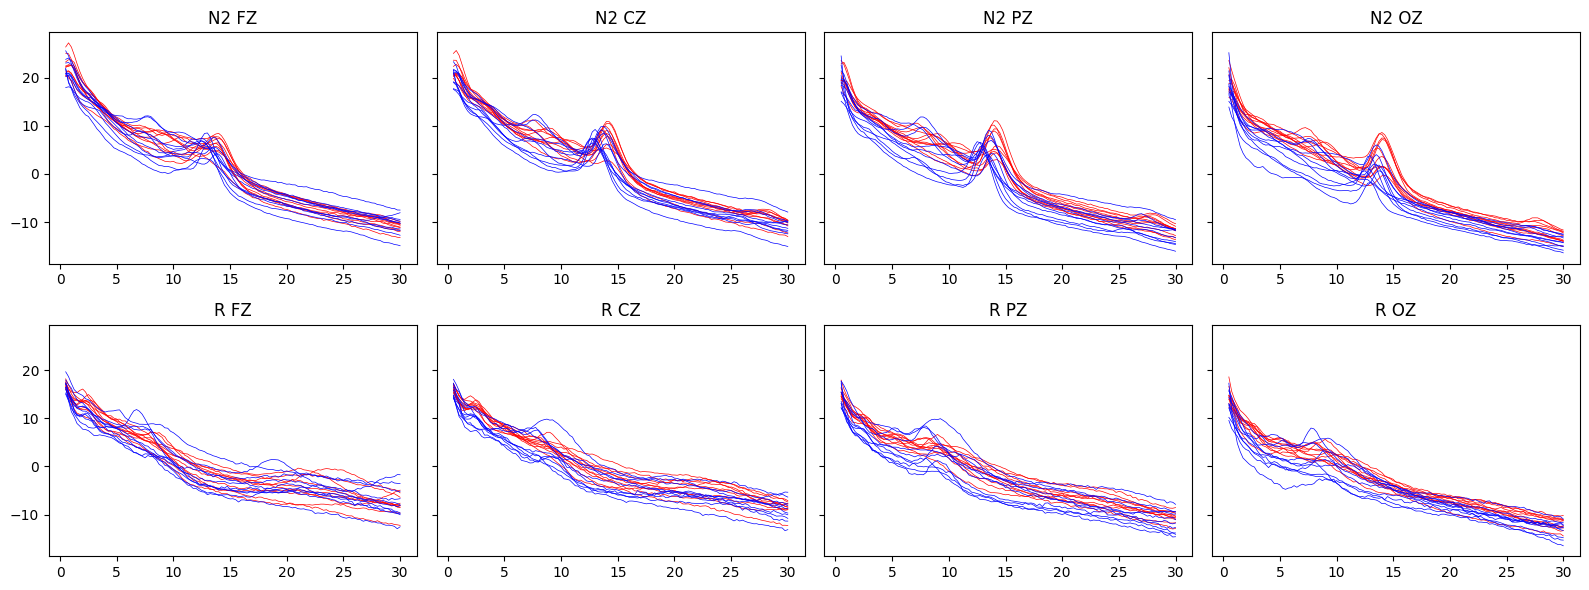

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey = True )  # 2 rows, 4 columns
idx = 0
ids = df_welch.ID.unique()
for stg in [ 'N2', 'R' ]:    
    for ch in [ 'FZ', 'CZ', 'PZ', 'OZ' ]:
        df = df_welch[ ( df_welch.stg == stg ) & ( df_welch.CH == ch ) ]
        ax = axes.flat[idx]
        for i in range(0,10):
            ax.plot( df.F[ df.ID == ids[i] ] , df.PSD[ df.ID == ids[i] ] , color = 'red' , lw=0.5)
        for i in range(10,20):
            ax.plot( df.F[ df.ID == ids[i] ] , df.PSD[ df.ID == ids[i] ] , color = 'blue' , lw=0.5)
        ax.set_title( stg + " " + ch )
        idx = idx + 1
plt.tight_layout()
plt.show()

## Sex differences

Finally, we can ask about potential sex differences in absolute spectral power. Here we'll consider just the FZ channel for N2 sleep:

In [14]:
ch = 'FZ'
stg = 'N2'

x_welch = df_welch[ ( df_welch.stg == stg ) & ( df_welch.CH == ch ) ][ [ 'male' , 'F' , 'PSD' ] ] 
x_mtm = df_mtm[ ( df_mtm.stg == stg ) & ( df_mtm.CH == ch ) ][ ['male' , 'F' , 'MTM'] ]
x_aper = df_irasa[ ( df_irasa.stg == stg ) & ( df_irasa.CH == ch ) ][ ['male' , 'F' , 'APER'] ] 
x_per = df_irasa[ ( df_irasa.stg == stg ) & ( df_irasa.CH == ch ) ][ ['male' , 'F' , 'PER'] ]


In [18]:
# run the t-tests here (for each freq. bin, using a helper function):
tt_welch = ttests_by_F( 'PSD' , x_welch ) 
tt_mtm = ttests_by_F( 'MTM' , x_mtm ) 
tt_aper = ttests_by_F( 'APER' , x_aper ) 
tt_per = ttests_by_F( 'PER' , x_per ) 

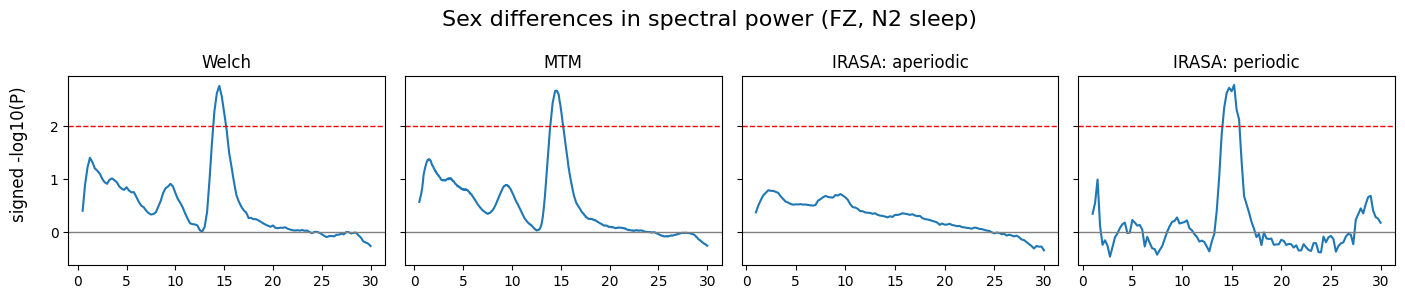

In [24]:
# and plot:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey = True )  # 2 rows, 4 columns
axes[0].plot( tt_welch.F , tt_welch.signed_log10_p ) 
axes[1].plot( tt_mtm.F , tt_mtm.signed_log10_p ) 
axes[2].plot( tt_aper.F , tt_aper.signed_log10_p ) 
axes[3].plot( tt_per.F , tt_per.signed_log10_p ) 
axes[0].set_title( 'Welch' )
axes[1].set_title( 'MTM' )
axes[2].set_title( 'IRASA: aperiodic' )
axes[3].set_title( 'IRASA: periodic' )
for ax in axes.flat:
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)  
    ax.axhline(y=2, color='red', linestyle='--', linewidth=1)  
fig.text(0.0, 0.5, 'signed -log10(P)',  va='center', rotation='vertical', fontsize=12)
fig.suptitle("Sex differences in spectral power (FZ, N2 sleep)", fontsize=16)
plt.tight_layout()
plt.show()

We've applied three different spectral methods to a subset of channels during N2 and REM sleep. We've observed the expected differences between stages (e.g. in particular increased sigma/spindle activity during N2 sleep). Further, there is a suggestion of sex differences in power between females and males.

---
We can now move on the [next section](03_dynam.ipynb) on ultradian dynamics.